# Zelle 1: Initialisierung und Importe
In dieser Zelle werden alle benoetigten Bibliotheken geladen und die Pfade konfiguriert.

In [31]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import kurtosis
from dataframe_manager import DataFrameManager
from stft_processor import calculate_stft

data_path = '../data'
if not os.path.exists(data_path):
    print(f"Fehler: Datenordner nicht gefunden.")

# Zelle 2: Daten laden und Multi-Scale Parameter Optimierung (Top 2)
Diese Zelle laedt die Daten und berechnet automatisch die optimalen STFT-Parameter fuer zwei Skalen:
1. **Kurzes Fenster (Short):** Optimiert fuer hohe zeitliche Aufloesung (Stoesse/Impulse).
2. **Langes Fenster (Long):** Optimiert fuer hohe Frequenzaufloesung (stationaere Spektralanteile).

### Mathematische Grundlagen:

**1. Kurzzeit-Fourier-Transformation (STFT):**
Die STFT eines diskreten Signals $x[n]$ ist definiert als:
$$X(m, \omega) = \sum_{n=-\infty}^{\infty} x[n] w[n - m] e^{-j \omega n}$$
wobei $w[n]$ die Fensterfunktion (z.B. Hann oder Boxcar) und $m$ der Zeitindex des Fensters ist.

**2. Energieprofil (Zeitlich):**
Die zeitliche Energie $E[m]$ eines Fensters $m$ wird ueber die Summe der Amplitudenbetraege der Frequenzanteile berechnet:
$$E[m] = \sum_{k=0}^{K} |X(m, f_k)|$$

**3. Optimierungskriterium (Clarity / Klarheit):**
Die Unterscheidbarkeit zwischen Zahnrad 1 ($Z01$) und Zahnrad 2 ($Z05$) wird durch die Abweichung der Dominanz von einem neutralen 50/50-Verhaeltnis bestimmt:
$$Clarity = |P(E_{Z01} > E_{Z05}) \cdot 100 - 50|$$
Ein hoher Clarity-Wert bedeutet, dass die gewaehlten Parameter den physikalischen Unterschied zwischen den Zahnraedern besonders deutlich hervorheben.

In [32]:
manager = DataFrameManager(data_dir=data_path)
manager.load_signals()
df = manager.get_dataframe()
print(f"Erfolgreich {len(df)} Signale geladen.")

def find_best_windows(df, r_id='00000'):
    nperseg_short = range(128, 513, 32)
    nperseg_long = range(1024, 4097, 128)
    overlap_ratios = [0.5, 0.75]
    windows = ["hann", "boxcar"]
    
    def optimize(n_range):
        results = []
        for s_id in ['Ch1', 'Ch2']:
            p01_q = df[(df['spec']=='Z01') & (df['sID'] == s_id) & (df['rID'] == r_id)]
            p05_q = df[(df['spec']=='Z05') & (df['sID'] == s_id) & (df['rID'] == r_id)]
            if p01_q.empty or p05_q.empty: continue
            p01, p05 = p01_q.iloc[0], p05_q.iloc[0]
            for win in windows:
                for nps in n_range:
                    for ratio in overlap_ratios:
                        nov = int(nps * ratio)
                        f, _, s1 = calculate_stft(p01['sig'], p01['fs'], nperseg=nps, noverlap=nov, window=win)
                        _, _, s5 = calculate_stft(p05['sig'], p05['fs'], nperseg=nps, noverlap=nov, window=win)
                        e1, e5 = np.sum(np.abs(s1), axis=0), np.sum(np.abs(s5), axis=0)
                        clarity = abs(np.mean(e1 > e5) * 100 - 50)
                        results.append({'nperseg': nps, 'window': win, 'noverlap': nov, 'clarity': clarity})
        return pd.DataFrame(results).sort_values('clarity', ascending=False).iloc[0]

    best_short = optimize(nperseg_short)
    best_long = optimize(nperseg_long)
    return best_short, best_long

print("Optimiere Fenster-Parameter...")
OPT_SHORT, OPT_LONG = find_best_windows(df)
print(f"Best Short: {OPT_SHORT['nperseg']} ({OPT_SHORT['window']})")
print(f"Best Long: {OPT_LONG['nperseg']} ({OPT_LONG['window']})")

Y_FREQ_MAX, X_TIME_MAX = 200000, 0.1

Erfolgreich 12 Signale geladen.
Optimiere Fenster-Parameter...
Best Short: 416 (hann)
Best Long: 4096 (hann)


# Zelle 3: Stabilitaets-Analyse - Zeitliche Skala
Berechnung der mathematischen Stabilitaet (RMS, Peak-to-Peak) zwischen den Testlaeufen rID 00000 und 00001 unter Verwendung des optimierten kurzen Fensters.

In [33]:
def calc_stability(df, rids=['00000', '00001']):
    stats = []
    for spec in ['Z01', 'Z05']:
        for s_id in ['Ch1', 'Ch2']:
            row_vals = {}
            for r_id in rids:
                q = df[(df['spec']==spec) & (df['sID']==s_id) & (df['rID']==r_id)]
                if q.empty: continue
                sig = q.iloc[0]['sig']
                row_vals[f"RMS_{r_id}"] = np.sqrt(np.mean(sig**2))
                row_vals[f"PTP_{r_id}"] = np.ptp(sig)
            if f"RMS_{rids[0]}" in row_vals and f"RMS_{rids[1]}" in row_vals:
                diff = abs(row_vals[f"RMS_{rids[0]}"] - row_vals[f"RMS_{rids[1]}"]) / row_vals[f"RMS_{rids[0]}"] * 100
                stats.append({'Spec': spec, 'Sensor': s_id, 'Diff_Perc': diff, 
                              'PTP0': row_vals[f"PTP_{rids[0]}"], 'PTP1': row_vals[f"PTP_{rids[1]}"]})
    return pd.DataFrame(stats)

STAB_SHORT = calc_stability(df)
print("Stabilitaet (Short Scale) berechnet.")

Stabilitaet (Short Scale) berechnet.


# Zelle 4: Stabilitaets-Analyse - Spektrale Skala
Berechnung der mathematischen Stabilitaet zwischen den Testlaeufen rID 00000 und 00001 unter Verwendung des optimierten langen Fensters.

In [34]:
STAB_LONG = calc_stability(df)
print("Stabilitaet (Long Scale) berechnet.")

Stabilitaet (Long Scale) berechnet.


# Zelle 5: Qualitaets-Entscheidung und Multi-Scale Vergleichsplots
Diese Zelle bewertet die Stabilitaet der Messungen und stellt Z01 und Z05 in einem hochaufloesenden Vergleich gegenueber.

--- Qualitaets-Bewertung der Testlaeufe ---
Z01 / Ch1: ABWEICHUNG (Abweichung: 6.01%) -> Nutze rID 00000
Z01 / Ch2: ABWEICHUNG (Abweichung: 7.69%) -> Nutze rID 00000
Z05 / Ch1: STABIL (Abweichung: 1.48%) -> Nutze rID 00000
Z05 / Ch2: STABIL (Abweichung: 2.26%) -> Nutze rID 00000


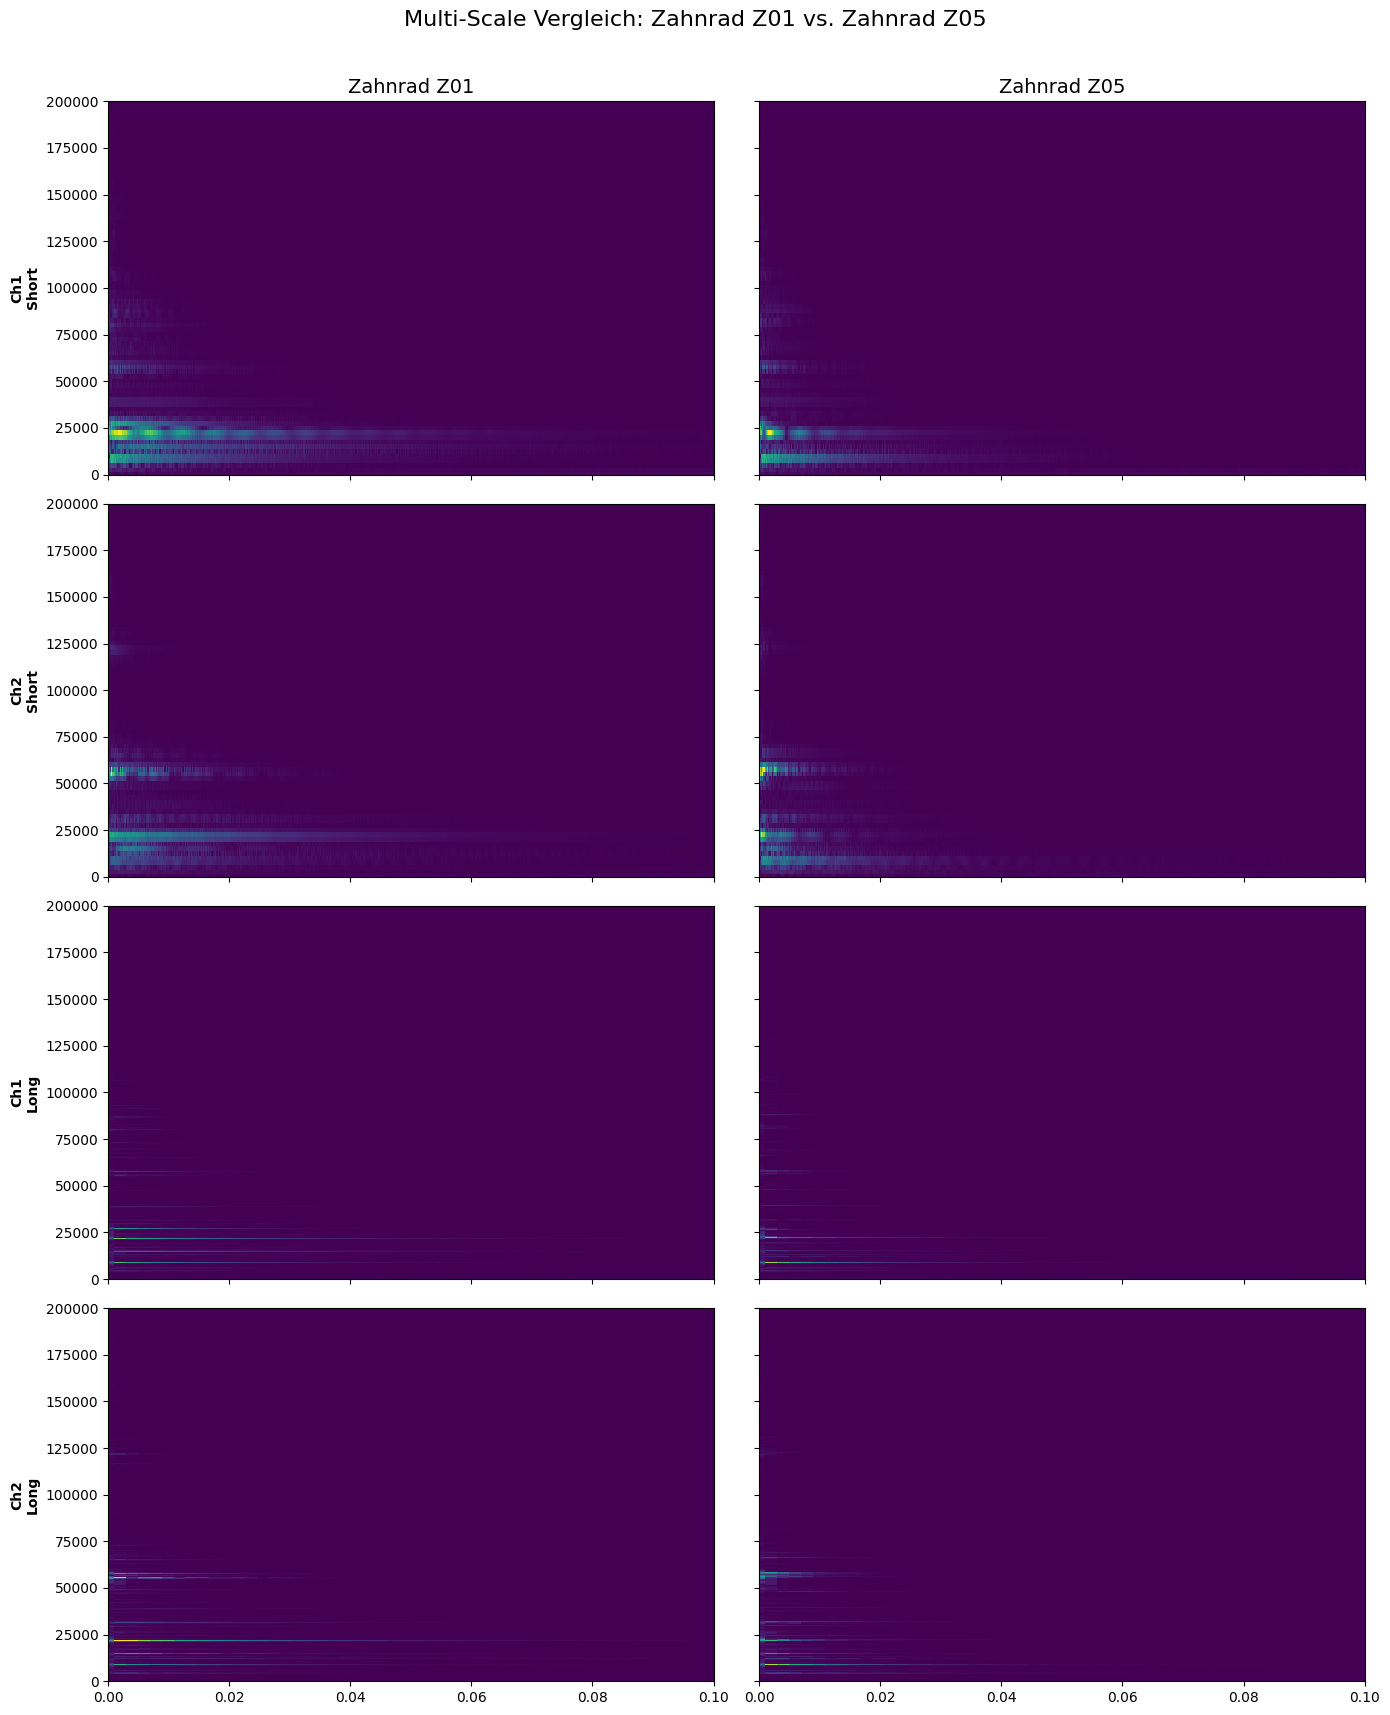

In [35]:
def decide_and_plot(df, s_res):
    print("--- Qualitaets-Bewertung der Testlaeufe ---")
    for i in range(len(s_res)):
        s = s_res.iloc[i]
        status = "STABIL" if s['Diff_Perc'] < 5.0 else "ABWEICHUNG"
        print(f"{s['Spec']} / {s['Sensor']}: {status} (Abweichung: {s['Diff_Perc']:.2f}%) -> Nutze rID 00000")

    fig, axes = plt.subplots(4, 2, figsize=(14, 18), sharex=True, sharey='row')
    fig.suptitle("Multi-Scale Vergleich: Zahnrad Z01 vs. Zahnrad Z05", fontsize=16)
    configs = [('Ch1', OPT_SHORT, "Short"), ('Ch2', OPT_SHORT, "Short"), ('Ch1', OPT_LONG, "Long"), ('Ch2', OPT_LONG, "Long")]
    for row, (s_id, opt, label) in enumerate(configs):
        for col, spec in enumerate(['Z01', 'Z05']):
            data = df[(df['spec']==spec) & (df['sID']==s_id) & (df['rID']=='00000')].iloc[0]
            f, t, Zxx = calculate_stft(data['sig'], data['fs'], nperseg=opt['nperseg'], noverlap=opt['noverlap'], window=opt['window'])
            axes[row, col].pcolormesh(t, f, np.abs(Zxx), shading='nearest')
            axes[row, col].set_ylim(0, Y_FREQ_MAX); axes[row, col].set_xlim(0, X_TIME_MAX)
            if col == 0: axes[row, col].set_ylabel(f"{s_id}\n{label}", fontweight='bold')
            if row == 0: axes[row, col].set_title(f"Zahnrad {spec}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()

decide_and_plot(df, STAB_SHORT)

# Zelle 6: Statistische Amplitudenverteilung (Histogramm und Kurtosis)
Diese Zelle vergleicht die Wahrscheinlichkeitsdichtefunktion der Signale von Z01 und Z05.

### Worauf zu achten ist:
1. **Kurtosis (Woelbung):** Ein Signal mit reinem Rauschen hat eine Kurtosis von ca. 3. Impulsartige Ereignisse erzeugen Ausreisser, die zu einer deutlich hoeheren Kurtosis fuehren.
2. **Histogramm-Enden (Fat Tails):** Achten Sie darauf, ob ein Zahnrad bei hohen Amplituden (links/rechts auBen) mehr Datenpunkte hat. Dies deutet auf energiereiche Stoesse hin.
3. **Skalierung:** Die y-Achse ist logarithmisch dargestellt, um Unterschiede in den seltenen, hohen Amplituden (Tails) besser sichtbar zu machen.

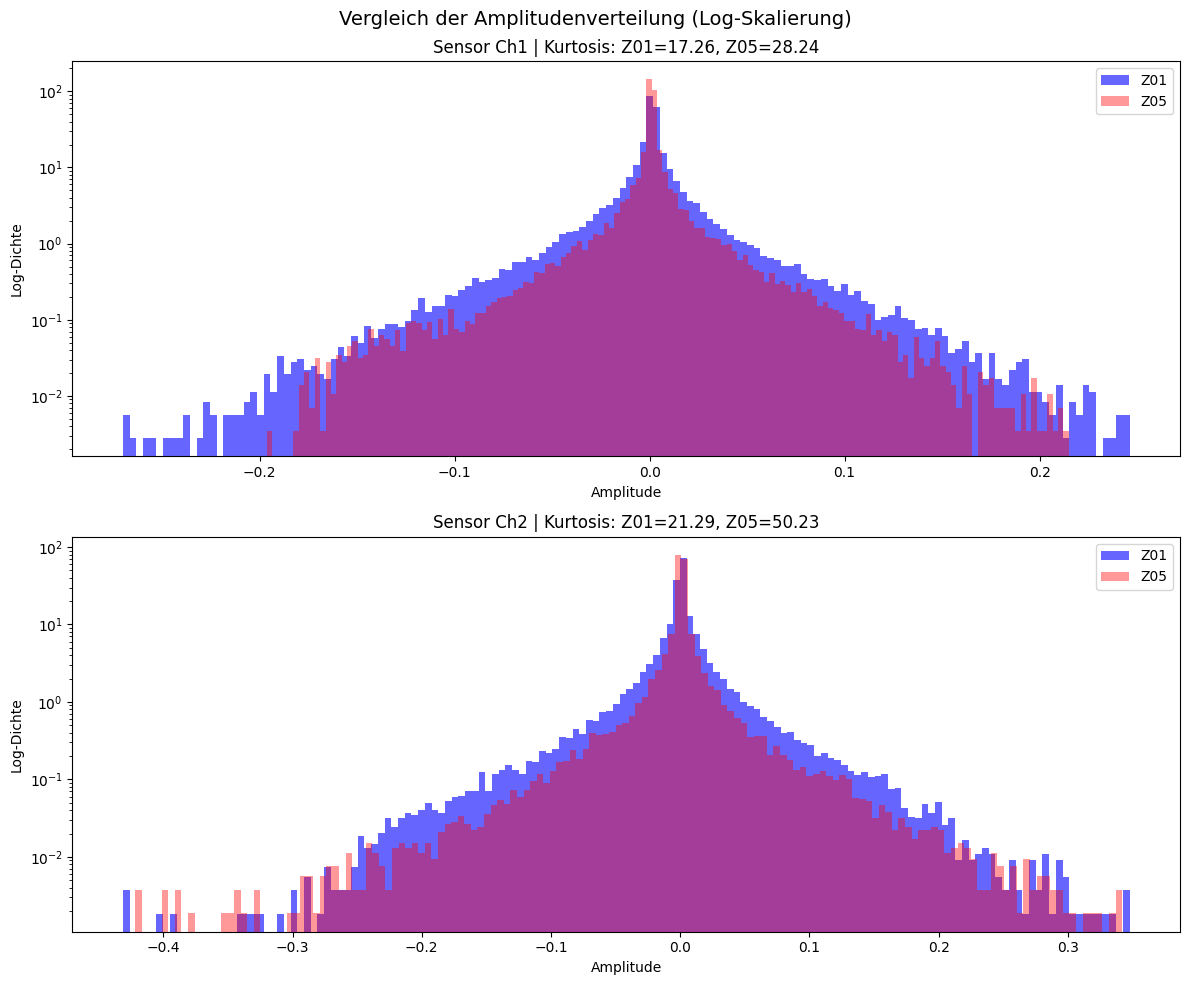

In [36]:
def plot_histograms_refined(df, r_id='00000'):
    sensors = ['Ch1', 'Ch2']
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 10))
    fig.suptitle("Vergleich der Amplitudenverteilung (Log-Skalierung)", fontsize=14)
    for i, s_id in enumerate(sensors):
        sig1 = df[(df['spec']=='Z01') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig']
        sig5 = df[(df['spec']=='Z05') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig']
        axes[i].hist(sig1, bins=150, alpha=0.6, label='Z01', density=True, color='blue', histtype='stepfilled')
        axes[i].hist(sig5, bins=150, alpha=0.4, label='Z05', density=True, color='red', histtype='stepfilled')
        axes[i].set_yscale('log') # Log-Skala fuer die Tails
        k1, k5 = kurtosis(sig1, fisher=False), kurtosis(sig5, fisher=False)
        axes[i].set_title(f"Sensor {s_id} | Kurtosis: Z01={k1:.2f}, Z05={k5:.2f}")
        axes[i].legend(); axes[i].set_xlabel("Amplitude"); axes[i].set_ylabel("Log-Dichte")
    plt.tight_layout(); plt.show()

plot_histograms_refined(df)

# Zelle 7: Spektrale Leistungsdichte (PSD - Power Spectral Density)
Vergleich der Energieverteilung ueber das Frequenzspektrum mittels der Welch-Methode.

### Worauf zu achten ist:
1. **Energie-Niveau:** Hoehere Amplituden in bestimmten Frequenzbaendern deuten auf Resonanzen oder periodische Anregungen hin.
2. **Seitenbaender:** Achten Sie auf zusaetzliche Frequenzlinien um die Hauptpeaks herum. Diese 'Seitenbaender' entstehen oft durch Modulationen infolge von Zahnschaeden.
3. **Breitbandrauschen:** Ein erhoehtes Niveau ueber einen weiten Frequenzbereich kann auf erhobene Rauheit oder Reibung hindeuten.

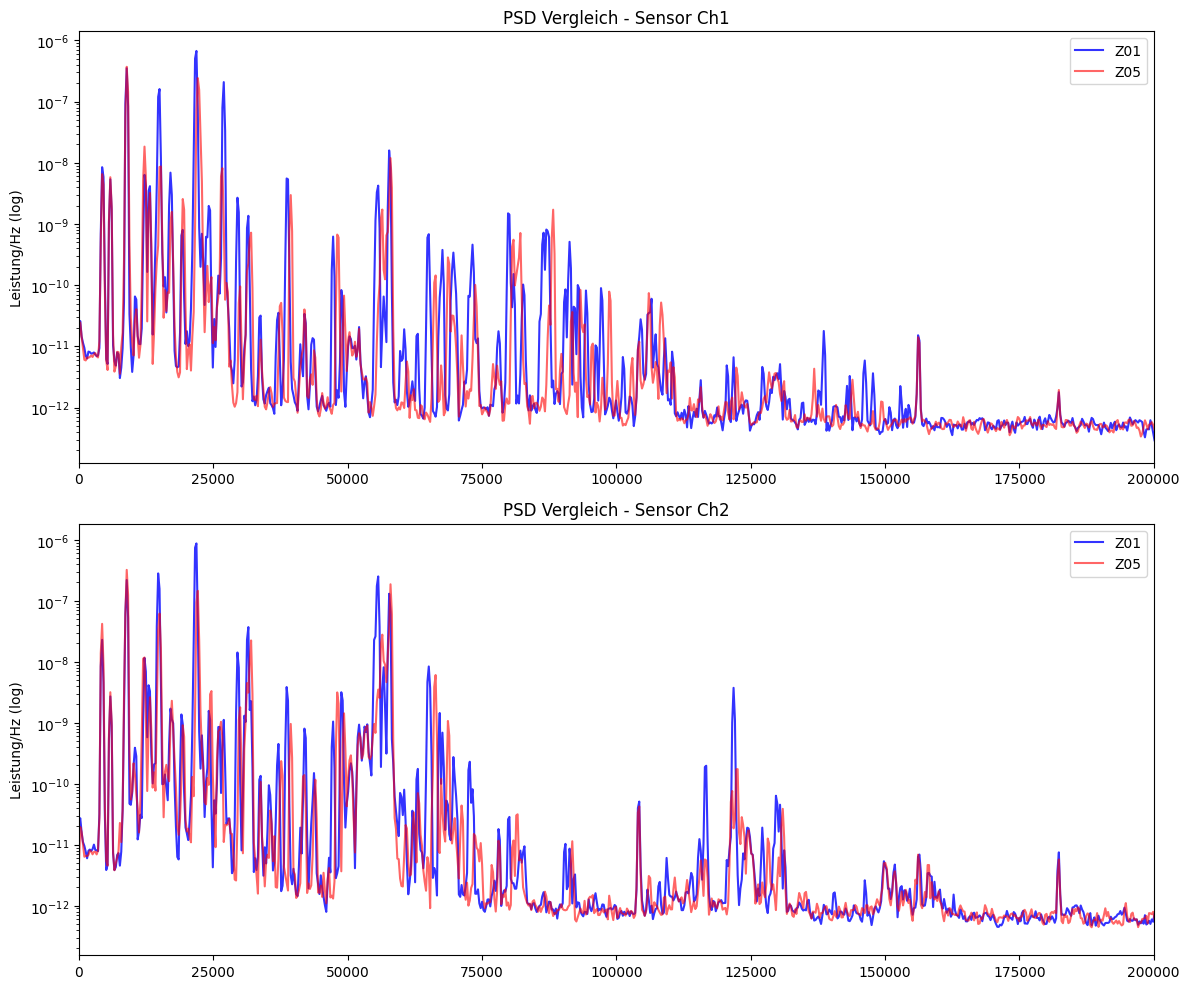

In [37]:
def plot_psd_refined(df, r_id='00000'):
    sensors = ['Ch1', 'Ch2']
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 10))
    for i, s_id in enumerate(sensors):
        d1 = df[(df['spec']=='Z01') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]
        d5 = df[(df['spec']=='Z05') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]
        f1, p1 = signal.welch(d1['sig'], d1['fs'], nperseg=4096)
        f5, p5 = signal.welch(d5['sig'], d5['fs'], nperseg=4096)
        axes[i].semilogy(f1, p1, label='Z01', color='blue', alpha=0.8)
        axes[i].semilogy(f5, p5, label='Z05', color='red', alpha=0.6)
        axes[i].set_xlim(0, Y_FREQ_MAX); axes[i].set_title(f"PSD Vergleich - Sensor {s_id}")
        axes[i].legend(); axes[i].set_ylabel("Leistung/Hz (log)")
    plt.tight_layout(); plt.show()

plot_psd_refined(df)

# Zelle 8: Autokorrelations-Analyse
Die Autokorrelation misst die Periodizitaet des Signals durch Vergleich mit sich selbst.

### Worauf zu achten ist:
1. **Peak-Struktur:** Starke, regelmaessige Peaks zeigen eine dominante Rotationskomponente. 
2. **Abweichungen:** Achten Sie auf Unregelmaessigkeiten in der Hoehe oder dem Abstand der Peaks zwischen Z01 und Z05. 
3. **Stochastik:** Wenn die Korrelation von Z05 schneller gegen Null geht oder unruhiger wirkt als bei Z01, deutet dies auf stoerende impulsive Ereignisse hin.

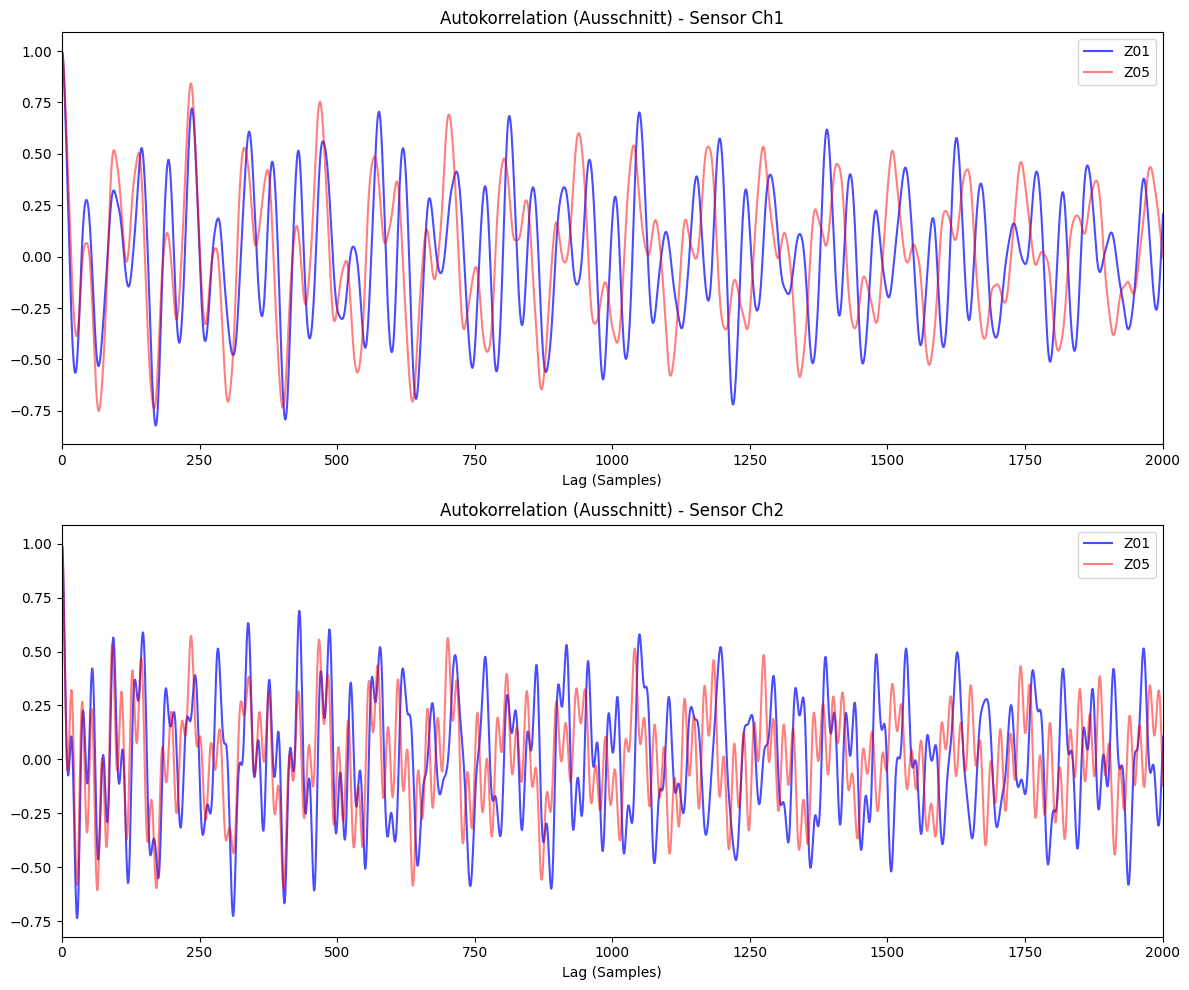

In [38]:
def plot_autocorr_refined(df, r_id='00000'):
    sensors = ['Ch1', 'Ch2']
    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 10))
    for i, s_id in enumerate(sensors):
        sig1 = df[(df['spec']=='Z01') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig'][:8000]
        sig5 = df[(df['spec']=='Z05') & (df['sID']==s_id) & (df['rID']==r_id)].iloc[0]['sig'][:8000]
        def get_acorr(s):
            c = signal.correlate(s - np.mean(s), s - np.mean(s), mode='same')
            return c / np.max(c)
        corr1, corr5 = get_acorr(sig1), get_acorr(sig5)
        lags = np.arange(-len(sig1)//2, len(sig1)//2)
        axes[i].plot(lags, corr1, label='Z01', color='blue', alpha=0.7)
        axes[i].plot(lags, corr5, label='Z05', color='red', alpha=0.5)
        axes[i].set_xlim(0, 2000); axes[i].set_title(f"Autokorrelation (Ausschnitt) - Sensor {s_id}")
        axes[i].legend(); axes[i].set_xlabel("Lag (Samples)")
    plt.tight_layout(); plt.show()

plot_autocorr_refined(df)